# XGBoost Project

## GraphX Labs ML Concepts Portfolio

Educational theme:

> What happens when machine learning starts learning from its own mistakes?

## 1. Problem Statement

We are predicting telecom customer churn.

Churn matters because losing customers means losing recurring revenue. If a company can identify high-risk customers earlier, it can prioritize retention action.

## 2. Why XGBoost?

Decision Trees are intuitive but can overfit.

Random Forest improves stability by asking many independent trees to vote.

XGBoost goes further. It builds trees sequentially. Each new tree focuses on what the current model still gets wrong.

Think of a teacher correcting a student: "You understand these questions, but you keep missing these. Focus there next."

## 3. Dataset Overview

Dataset: IBM Telco Customer Churn.

Target: `churn`

- `1`: churned
- `0`: stayed

Features include contract type, tenure, monthly charges, total charges, internet service, tech support, and payment method.

## 4. Import Libraries

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

from xgboost import XGBClassifier
import shap

sns.set_theme(style="whitegrid")
PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()
DATA_RAW = PROJECT_ROOT / "data" / "raw" / "telco_customer_churn.csv"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed" / "telco_customer_churn_processed.csv"
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

## 5. Load Dataset

In [2]:
raw_df = pd.read_csv(DATA_RAW)
raw_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 6. Initial Data Inspection

In [3]:
print("Shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.describe(include="all").T.head(25))

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print("Missing values:")
display(raw_df.isna().sum().sort_values(ascending=False).head())
print("Duplicate rows:", raw_df.duplicated().sum())
display(raw_df["Churn"].value_counts(normalize=True).rename("proportion"))

Missing values:


customerID          0
DeviceProtection    0
TotalCharges        0
MonthlyCharges      0
PaymentMethod       0
dtype: int64

Duplicate rows: 0


No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## 7. Exploratory Data Analysis

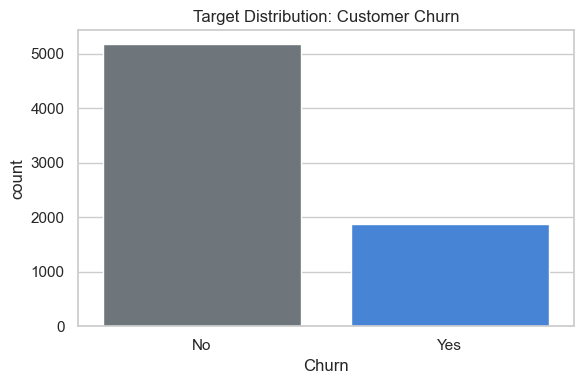

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=raw_df, x="Churn", palette=["#6C757D", "#2F80ED"])
plt.title("Target Distribution: Customer Churn")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

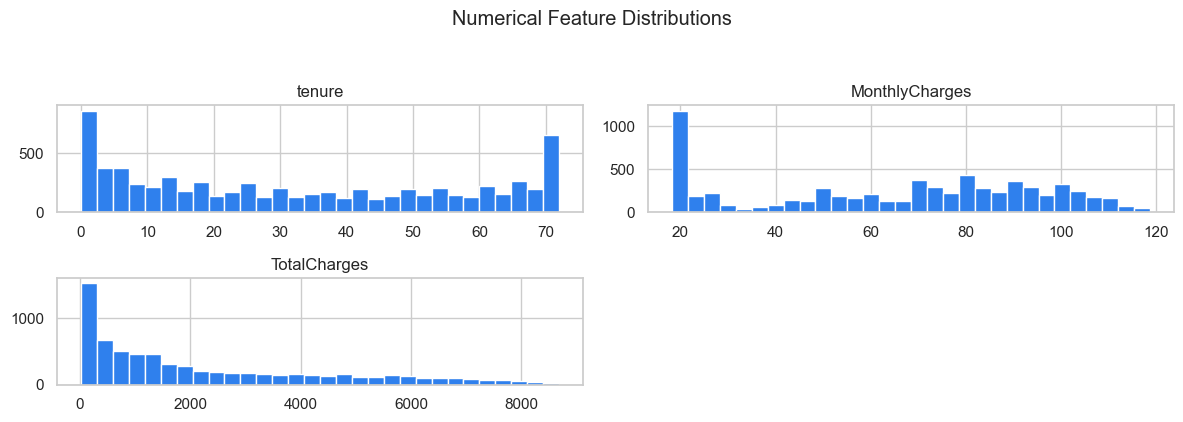

In [7]:
plot_df = raw_df.copy()
plot_df["TotalCharges"] = pd.to_numeric(plot_df["TotalCharges"], errors="coerce")
plot_df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(figsize=(12, 4), bins=30, color="#2F80ED", edgecolor="white")
plt.suptitle("Numerical Feature Distributions", y=1.05)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "numerical_feature_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

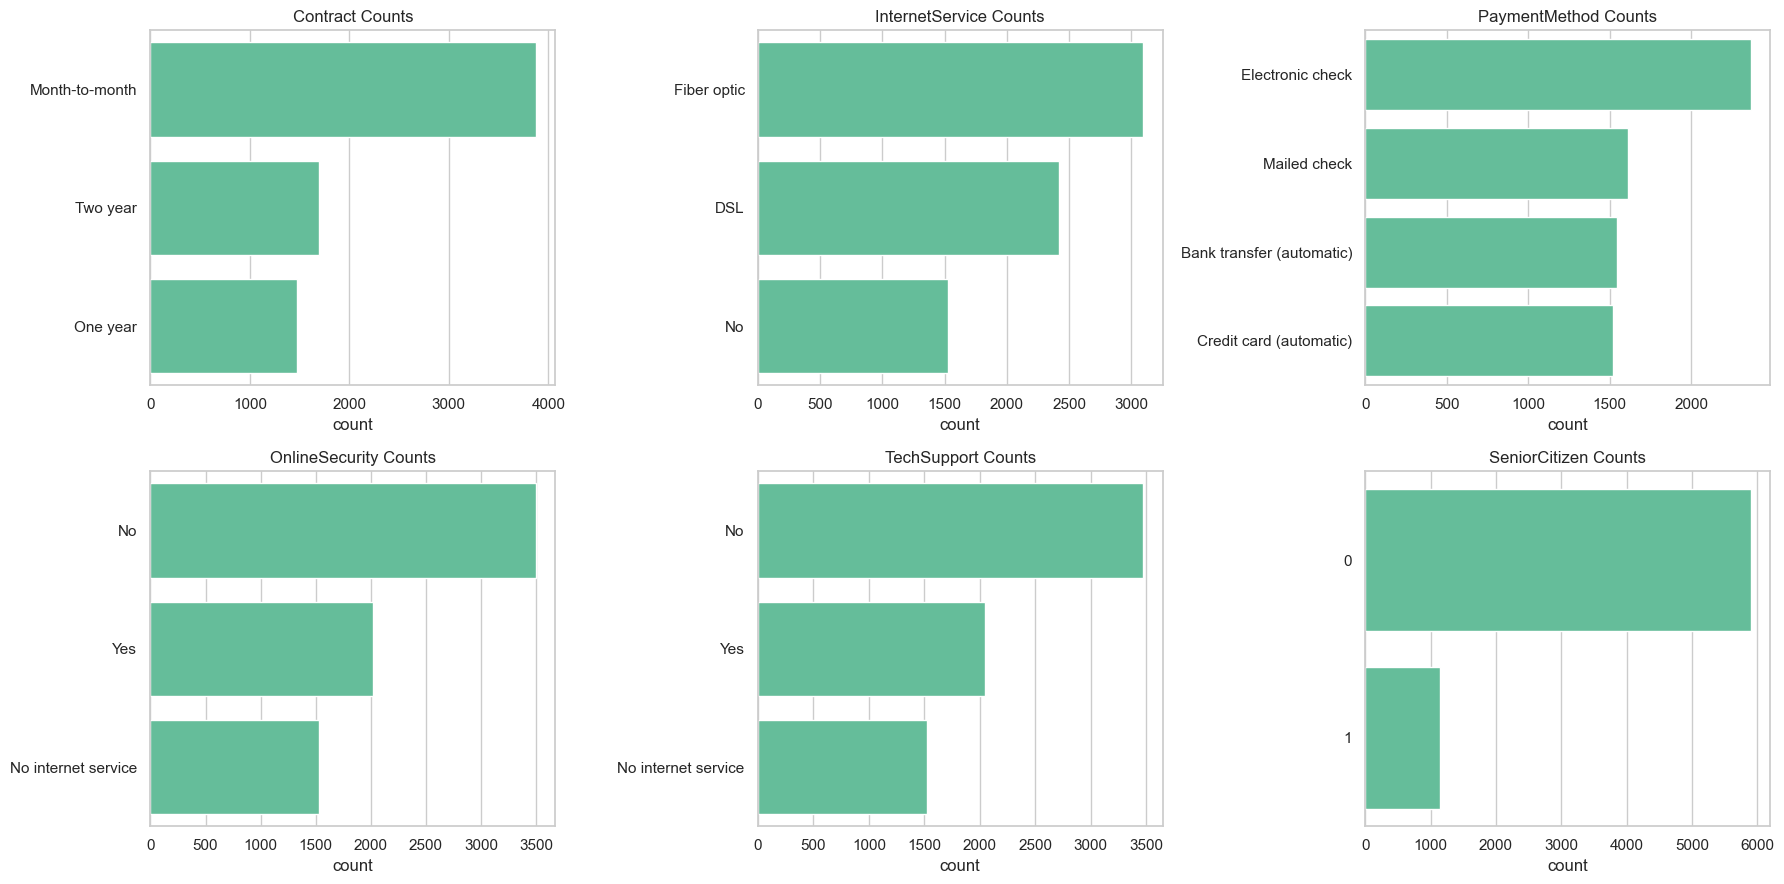

In [8]:
categorical_features = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "SeniorCitizen"]
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for ax, column in zip(axes, categorical_features):
    order = raw_df[column].value_counts().index
    sns.countplot(data=raw_df, y=column, order=order, ax=ax, color="#56CC9D")
    ax.set_title(f"{column} Counts")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "categorical_feature_counts.png", dpi=300, bbox_inches="tight")
plt.show()

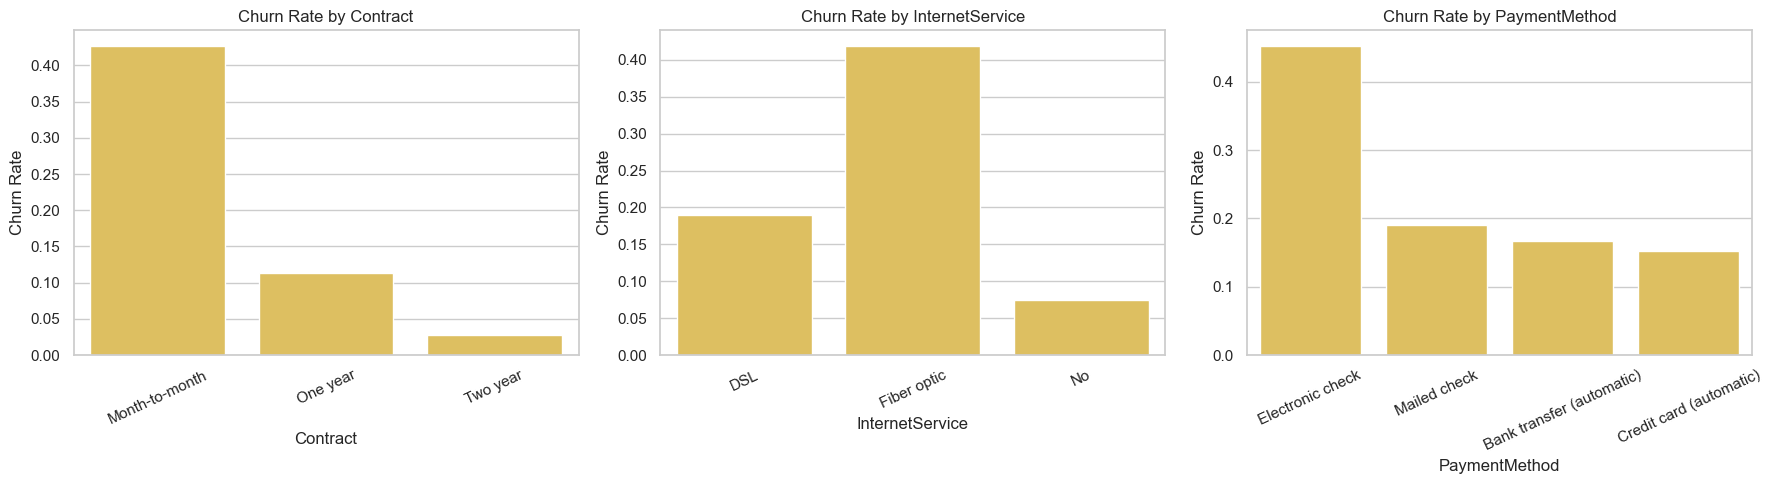

In [9]:
rel_df = raw_df.copy()
rel_df["churn_flag"] = (rel_df["Churn"] == "Yes").astype(int)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ["Contract", "InternetService", "PaymentMethod"]):
    sns.barplot(data=rel_df, x=column, y="churn_flag", ax=ax, ci=None, color="#F2C94C")
    ax.set_title(f"Churn Rate by {column}")
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_relationships.png", dpi=300, bbox_inches="tight")
plt.show()

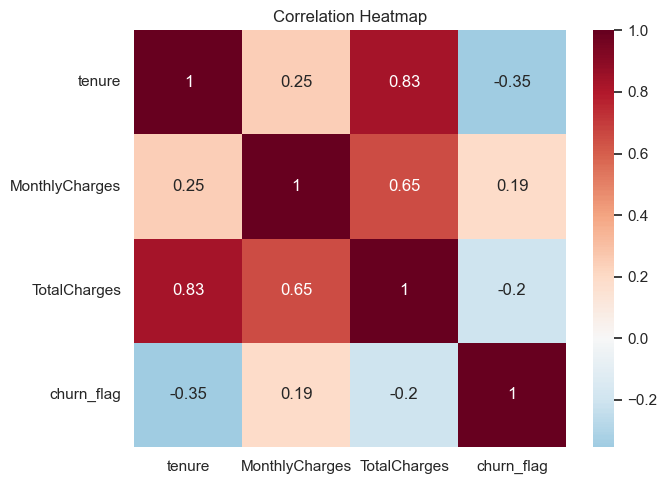

In [10]:
corr_df = plot_df.copy()
corr_df["churn_flag"] = (corr_df["Churn"] == "Yes").astype(int)
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df[["tenure", "MonthlyCharges", "TotalCharges", "churn_flag"]].corr(), annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Data Cleaning

In [11]:
df = raw_df.copy()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
df["totalcharges"] = pd.to_numeric(df["totalcharges"], errors="coerce")
df["totalcharges"] = df["totalcharges"].fillna(df["totalcharges"].median())
df = df.drop_duplicates().copy()
df["churn"] = df["churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerid"])
df.to_csv(DATA_PROCESSED, index=False)
print("Cleaned shape:", df.shape)
display(df.head())

Cleaned shape: (7043, 20)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 9. Feature Engineering

In [12]:
X = df.drop(columns=["churn"])
y = df["churn"]
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_columns, drop_first=True)
print("Encoded feature shape:", X_encoded.shape)

Encoded feature shape: (7043, 30)


XGBoost does not require feature scaling because tree splits use thresholds, not distance.

## 10. Train-Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


## 11. Build Baseline Models

In [14]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_prob = model.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "precision": precision_score(y_test, test_pred, zero_division=0),
        "recall": recall_score(y_test, test_pred, zero_division=0),
        "f1": f1_score(y_test, test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, test_prob),
    }

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
decision_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
random_forest = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=1)

logistic_model.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

baseline_results = pd.DataFrame([
    evaluate_model("Logistic Regression", logistic_model, X_train, y_train, X_test, y_test),
    evaluate_model("Decision Tree", decision_tree, X_train, y_train, X_test, y_test),
    evaluate_model("Random Forest", random_forest, X_train, y_train, X_test, y_test),
])
baseline_results

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.806709,0.806955,0.658385,0.566845,0.609195,0.841649
1,Decision Tree,0.998048,0.738822,0.507937,0.513369,0.510638,0.666359
2,Random Forest,0.857472,0.806246,0.674740,0.521390,0.588235,0.843486


We move to XGBoost because it can learn sequentially: every new tree focuses on what the current ensemble still gets wrong.

## 12. Build XGBoost Model

In [15]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1
)
xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)
evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)

{'model': 'XGBoost',
 'train_accuracy': 0.8267660631877884,
 'test_accuracy': 0.7998580553584103,
 'precision': 0.6543624161073825,
 'recall': 0.5213903743315508,
 'f1': 0.5803571428571429,
 'roc_auc': 0.84440827714485}

XGBoost parameters intuitively:

- `n_estimators`: how many correction steps
- `learning_rate`: how loudly each tree speaks
- `max_depth`: how complex each tree can be
- `subsample`: how many rows each tree sees
- `colsample_bytree`: how many features each tree sees

## 13. Model Evaluation

In [16]:
results_df = pd.concat([
    baseline_results,
    pd.DataFrame([evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)])
], ignore_index=True)
results_df

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.806709,0.806955,0.658385,0.566845,0.609195,0.841649
1,Decision Tree,0.998048,0.738822,0.507937,0.513369,0.510638,0.666359
2,Random Forest,0.857472,0.806246,0.674740,0.521390,0.588235,0.843486
3,XGBoost,0.826766,0.799858,0.654362,0.521390,0.580357,0.844408


In [17]:
print(classification_report(y_test, xgb_pred, target_names=["No Churn", "Churn"], zero_division=0))

              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



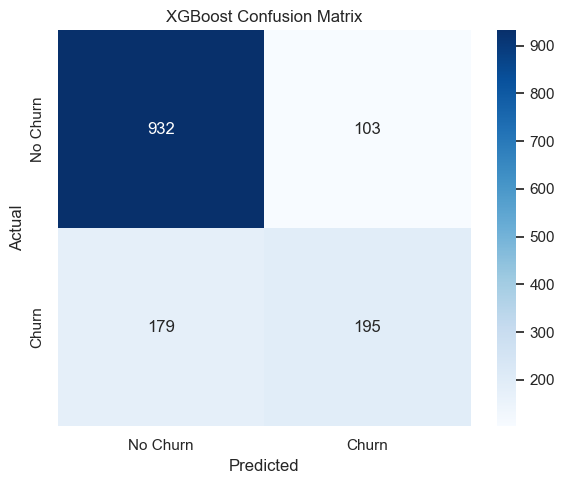

In [18]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

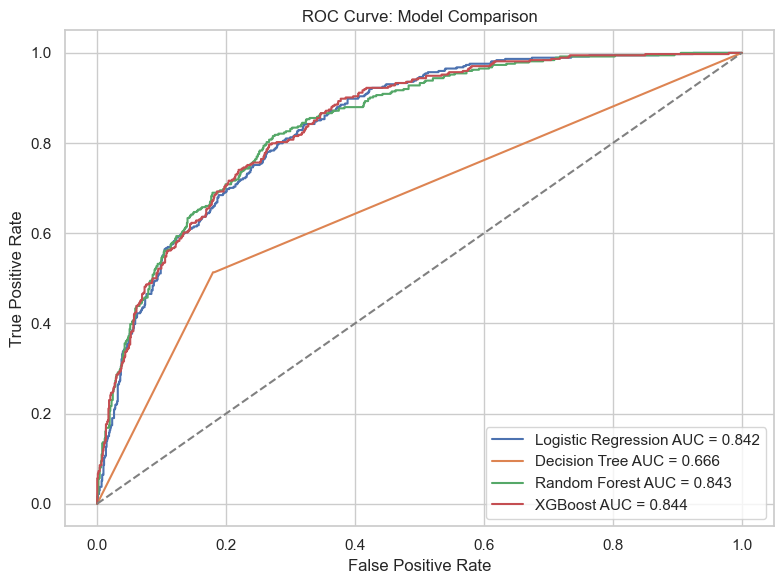

In [19]:
plt.figure(figsize=(8, 6))
for name, model in [
    ("Logistic Regression", logistic_model),
    ("Decision Tree", decision_tree),
    ("Random Forest", random_forest),
    ("XGBoost", xgb_model),
]:
    prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

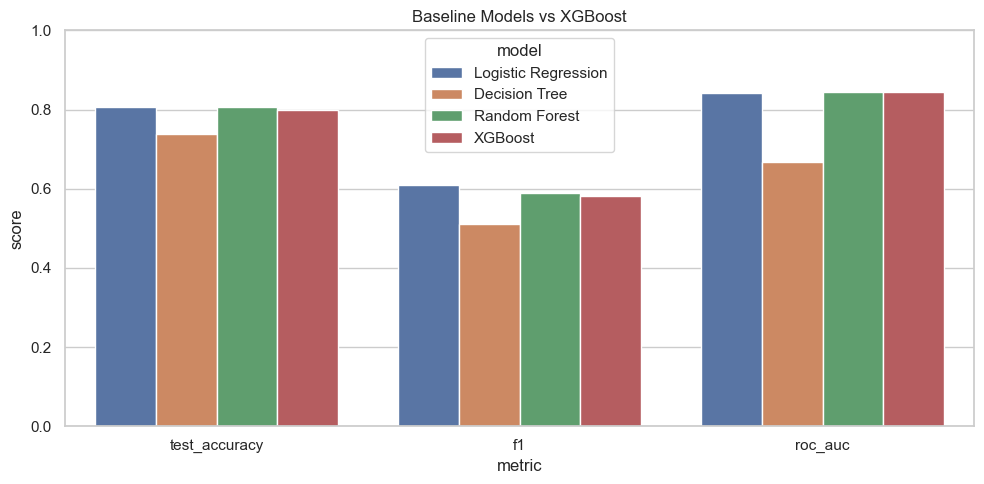

In [20]:
comparison_plot = results_df.melt(id_vars="model", value_vars=["test_accuracy", "f1", "roc_auc"], var_name="metric", value_name="score")
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_plot, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Baseline Models vs XGBoost")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 14. Why XGBoost Performs Better

XGBoost performs well because it is not just averaging trees. It is building a sequence of corrections.

Random Forest says: "Let many trees vote."

XGBoost says: "Look at the mistakes, then build the next tree to reduce them."

That sequential correction helps capture nonlinear patterns and feature interactions while regularization keeps the model from becoming too wild.

## 15. Feature Importance

,feature,importance
10,internetservice_Fiber optic,71.023331
25,contract_Two year,63.236187
24,contract_One year,46.668476
28,paymentmethod_Electronic check,31.999063
11,internetservice_No,26.216017
12,onlinesecurity_No internet service,21.360832
1,tenure,17.331730
23,streamingmovies_Yes,9.862334
13,onlinesecurity_Yes,9.686028
26,paperlessbilling_Yes,8.926834


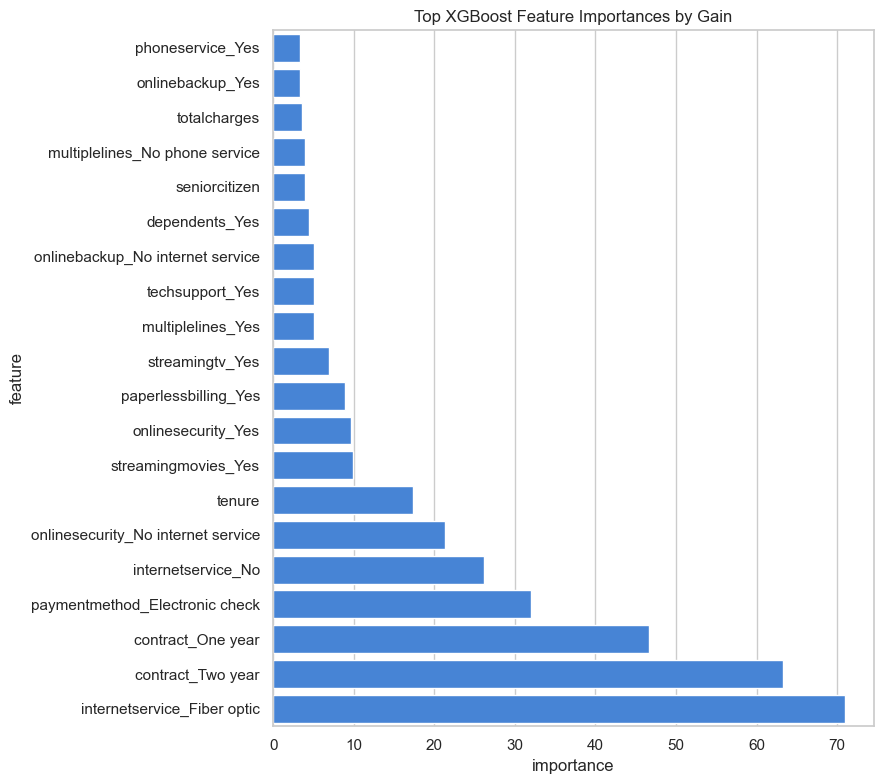

In [21]:
booster = xgb_model.get_booster()
gain_scores = booster.get_score(importance_type="gain")
importance_df = pd.DataFrame({
    "feature": X_encoded.columns,
    "importance": [gain_scores.get(feature, 0) for feature in X_encoded.columns]
}).sort_values("importance", ascending=False)
display(importance_df.head(20))

plt.figure(figsize=(9, 8))
top_importance = importance_df.head(20).sort_values("importance")
sns.barplot(data=top_importance, x="importance", y="feature", color="#2F80ED")
plt.title("Top XGBoost Feature Importances by Gain")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Gain means how much a feature improved the model when used in splits. Weight means how often it was used. Cover means how many samples were affected.

## 16. Hyperparameter Tuning

In [22]:
param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}
grid_search = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=1),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=1
)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 4))

Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}
Best CV ROC-AUC: 0.8509


In [23]:
tuned_xgb = grid_search.best_estimator_
tuned_metrics = evaluate_model("Tuned XGBoost", tuned_xgb, X_train, y_train, X_test, y_test)
pd.DataFrame([tuned_metrics])

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Tuned XGBoost,0.818424,0.800568,0.662021,0.508021,0.574887,0.846134


A smaller learning rate often helps because the model takes smaller correction steps. The tradeoff is that it usually needs more trees.

## 17. SHAP Explainability

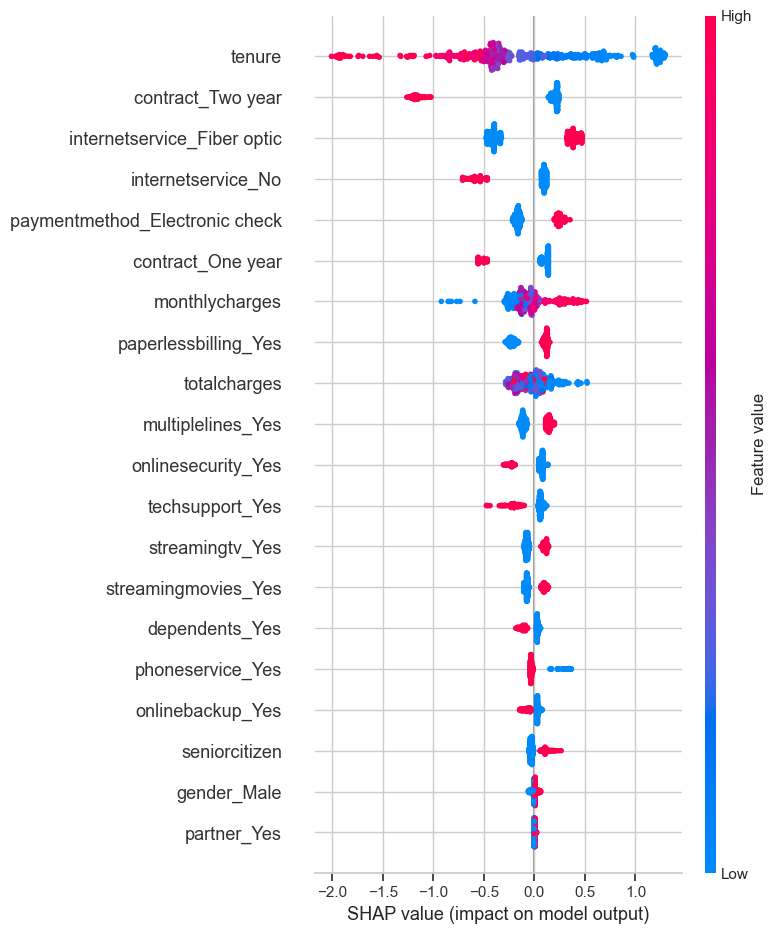

In [24]:
shap_sample = X_test.sample(n=min(500, len(X_test)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(tuned_xgb)
shap_values = explainer.shap_values(shap_sample)

plt.figure()
shap.summary_plot(shap_values, shap_sample, show=False, max_display=20)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "shap_summary.png", dpi=300, bbox_inches="tight")
plt.show()

SHAP explains how features push predictions toward or away from churn.

Global interpretability asks: what patterns matter overall?

Local interpretability asks: why did this specific customer receive this prediction?

## 18. Limitations of XGBoost

XGBoost is powerful, but it has tradeoffs:

- training can be slower than simple models
- hyperparameters matter
- it can overfit
- it is less directly interpretable than Logistic Regression
- explainability often needs tools like SHAP

## 19. Final Model Summary

In [25]:
final_results = pd.concat([results_df, pd.DataFrame([tuned_metrics])], ignore_index=True)
final_results

,model,train_accuracy,test_accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.806709,0.806955,0.658385,0.566845,0.609195,0.841649
1,Decision Tree,0.998048,0.738822,0.507937,0.513369,0.510638,0.666359
2,Random Forest,0.857472,0.806246,0.674740,0.521390,0.588235,0.843486
3,XGBoost,0.826766,0.799858,0.654362,0.521390,0.580357,0.844408
4,Tuned XGBoost,0.818424,0.800568,0.662021,0.508021,0.574887,0.846134


## 20. Key Learnings

- XGBoost learns sequentially from mistakes.
- Weak learners can become a strong learner.
- `learning_rate` controls correction strength.
- Regularization and sampling help reduce overfitting.
- SHAP makes powerful models easier to explain.

## 21. Interview Questions

See the companion file:

`xgboost/interview_questions.md`